## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Parameter für das Experiment: Wähle die gewollten Lösungen $x_0$ und $x_1$ (später konstruieren wir das Problem so, dass diese die tatsächlichen Lösungen sein werden).

In [2]:
n = 500
x_max = 750

x0 = np.linspace(2, x_max, n) # Nullstelle 0
x1 = 1 / x0                   # Nullstelle 1 (nach Vieta)

Setze $a$ und $b$ _vektorisiert_ so, dass $x_0$ und $x_1$ jeweils die Nullstellen sind. 

In [3]:
a = -(x0 + x1)
b = 1

Methode für klassische Nullstellensuche mit _Mitternachtsformel_:

In [4]:
def sq_solve(a, b):
    z = np.array([])
    D = a**2 - 4*b
    if D.any() < 0: 
        raise ValueError("No real Zeros")
    else:
        wD = np.sqrt(D)
        return (-a + wD)/2 , (-a - wD)/2

Berechne die Nullstellen und vergleiche mit den tatsächlichen Nullstellen:

In [5]:
x0_naive, x1_naive = sq_solve(a,b) # Fehlerbehaftete Berechnung
err0_naive = abs(x0_naive - x0)/x0
err1_naive = abs(x1_naive - x1)/x1

## Plot
Hier sehen wir den Fehler der Nullstellensuche mithilfe der normalen quadratischen Gleichung, der aufgrund der ungenauen Zahlendarstellung des Computers passiert (Auslöschung bei kleiner Nullstelle):

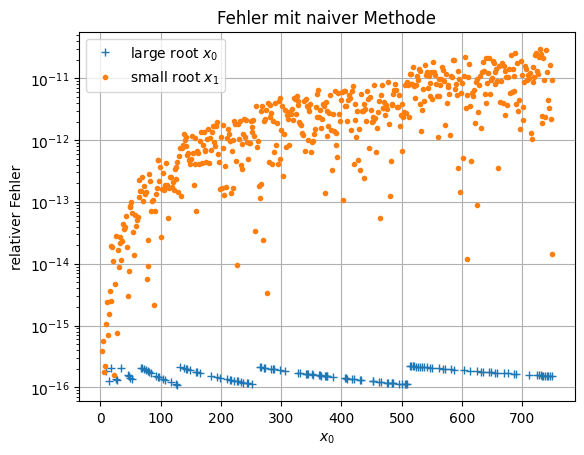

In [6]:
plt.title("Fehler mit naiver Methode")
plt.semilogy(x0, err0_naive, '+', label=r'large root $x_0$')
plt.semilogy(x0, err1_naive, '.', label=r'small root $x_1$')
plt.ylabel('relativer Fehler')
plt.xlabel(r'$x_0$')
plt.grid()
plt.legend()
plt.show()

## Alternative variante
Um die Auslöschung zu verhindern, suchen wir wieder nach der 'grossen Wurzel' von vorher und nutzen, dass $x_0 = \frac{1}{x_1}$ für die beiden Nullstellen. So berechnen wir die zweite Nullstelle _ohne_ subtraktion. 

In [7]:
def sq_solve_vieta(a,b):
    z = np.array([])
    D = a**2 - 4*b
    if D.any()<0: 
        print('no real zeros')
    else:
        wD = np.sqrt(D)
        z1 = np.where(a<0, (wD-a)/2, (-wD-a)/2)
        z2 = b/z1
        z = np.array([z1, z2])
        return(z)

Berechnung der Nullstellen mit der verbesserten Methode und Berechnung relativer Fehler:

In [8]:
x0_vieta, x1_vieta = sq_solve_vieta(a,b)
err0_vieta = abs(x0_vieta - x0)/x0
err1_vieta = abs(x1_vieta - x1)/x1

Plot im Vergleich:

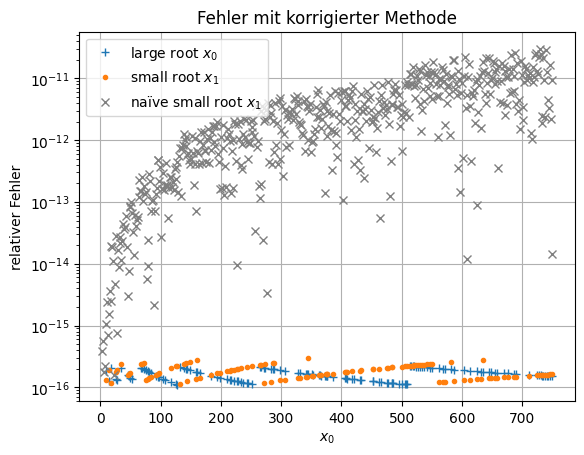

In [12]:
plt.title("Fehler mit korrigierter Methode")
plt.semilogy(x0, err0_vieta, '+', label=r'large root $x_0$')
plt.semilogy(x0, err1_vieta, '.', label=r'small root $x_1$')
plt.semilogy(x0, err1_naive, 'x', label=r'naïve small root $x_1$', color="gray")
plt.ylabel('relativer Fehler')
plt.xlabel(r'$x_0$')
plt.grid()
plt.legend()
plt.show()